#Deteksi Makronutiren Makanan Khas Bogor dengan YOLOv8 Segmentation

Nama  : Danar Mas Saputra

Kelas : 3IA02

NPM   : 50423331

#**1. Business Understanding**

**Latar Belakang**

Bogor memiliki kekayaan kuliner tradisional yang khas, namun banyak masyarakat, terutama pendatang dan wisatawan, belum mengenal jenis maupun kandungan gizi dari hidangan-hidangan tersebut. Di sisi lain, meningkatnya kesadaran akan pola makan sehat mendorong kebutuhan alat bantu yang dapat mengidentifikasi makanan sekaligus menampilkan informasi nutrisinya secara cepat. Penelitian ini membangun model computer vision sebagai lapisan deteksi pada aplikasi pelacak nutrisi (nutrition tracker) yang mengenali makanan khas Bogor dari citra, untuk kemudian ditautkan dengan data kalori dan makronutrien.

**Tujuan**

Membangun sebuah model YOLOv8 instace segmentation yang mampu mendetksi lima kelas makanan khas Bogor, mengevaluasi performanya menggunakan metrik mAP, serta mendemonstrasikan integrasinya dengan basis data nutrisi tabular sehingga setiap hidangan yang terdeteksi dapat menampilkan estimasi kandungan gizinya.

**Ruang Lingkup dan Batasan**

- Model dibatasi pada lima kelas makanan khas Bogor yang dipilih berdasarkan keaslian asal daerah: Doclang, Toge Goreng, dan Cungkring (kategori autentik Bogor tanpa klaim daerah lain), serta Laksa Bogor dan Asinan Bogor (kategori varian dengan versi Bogor yang diakui).
- Cakupan penelitian terbatas pada lapisan deteksi, yaitu identifikasi dan segmentasi hidangan. Estimasi berat/porsi serta pencarian data nutrisi ditangani pada sisi backend dan berada di luar fokus utama pemodelan.
- Data nutrisi digunakan sebatas proses pencarian (lookup) untuk keperluan demonstrasi integrasi end-to-end, bukan pengolahan ulang dataset tabular.

#**2. DATA UNDERSTANDING**


##2.1 Import Library

In [22]:
# Step 1 = install ultralytics (YOLOv8)
!pip install ultralytics -q

# Step 2 = library core
import os
import glob
import shutil
import random
import yaml
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from ultralytics import YOLO
from IPython.display import Image, display

# Step 3 = setup seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print("Finish")

Finish


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##2.2 Load Dataset

In [32]:
# Step 1 = buat path dari dataset gambar clean
SOURCE_DIR = "/content/drive/MyDrive/Nutrify_AI_Mobile-PI-Gundar/Datasets/Dataset_Image/Clean"

# Step 2 = baca data, yaml
with open(os.path.join(SOURCE_DIR, "data.yaml")) as f:
  data_cfg = yaml.safe_load(f)

CLASS_NAMES = data_cfg["names"]
NC = len(CLASS_NAMES)
print(f"Jumlah kelas (nc): {NC}")
print(f"Nama kelas: {CLASS_NAMES}")


Jumlah kelas (nc): 5
Nama kelas: ['Asinan Bogor', 'Cungkring', 'Doclang', 'Laksa', 'Toge Goreng']


##2.3 Dataset Overview

###2.3.1 Cek struktur folder

In [4]:
# Step 1: cek split apa saja yang tersedia
for split in ["train", "valid", "test"]:
    img_dir = os.path.join(SOURCE_DIR, split, "images")
    n = len(glob.glob(os.path.join(img_dir, "*.*"))) if os.path.isdir(img_dir) else 0
    status = "ADA" if os.path.isdir(img_dir) else "TIDAK ADA"
    print(f"{split:6s}: {status:9s} ({n} gambar)")

train : ADA       (316 gambar)
valid : TIDAK ADA (0 gambar)
test  : TIDAK ADA (0 gambar)


###2.3.2 Distribusi kelas

Asinan Bogor    : 86
Doclang         : 67
Toge Goreng     : 60
Laksa           : 56
Cungkring       : 56


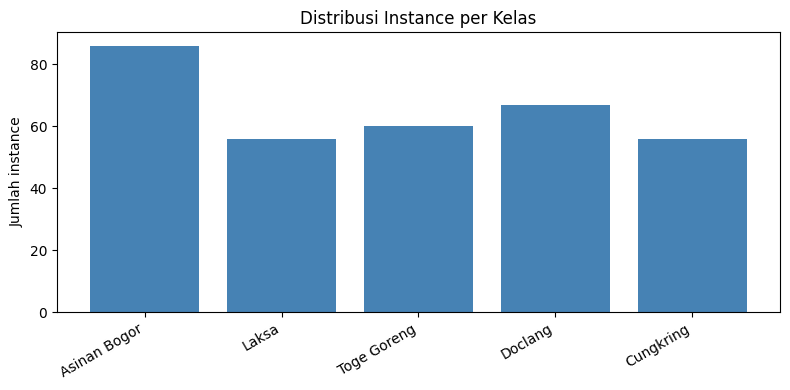

In [5]:
# Step 1: hitung jumlah instance per kelas dari file label .txt
def hitung_distribusi(label_dir):
    counter = Counter()
    for txt in glob.glob(os.path.join(label_dir, "*.txt")):
        with open(txt) as f:
            for line in f:
                if line.strip():
                    cls_id = int(line.split()[0])
                    counter[CLASS_NAMES[cls_id]] += 1
    return counter

# Step 2: tampilkan distribusi dari folder train (sumber utama sebelum split)
dist = hitung_distribusi(os.path.join(SOURCE_DIR, "train", "labels"))
for nama, jml in sorted(dist.items(), key=lambda x: -x[1]):
    print(f"{nama:16s}: {jml}")

# Step 3: plot bar chart distribusi kelas
plt.figure(figsize=(8, 4))
plt.bar(dist.keys(), dist.values(), color="steelblue")
plt.title("Distribusi Instance per Kelas")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Jumlah instance")
plt.tight_layout()
plt.show()

###2.3.3 Visualisasi sample + anotasi

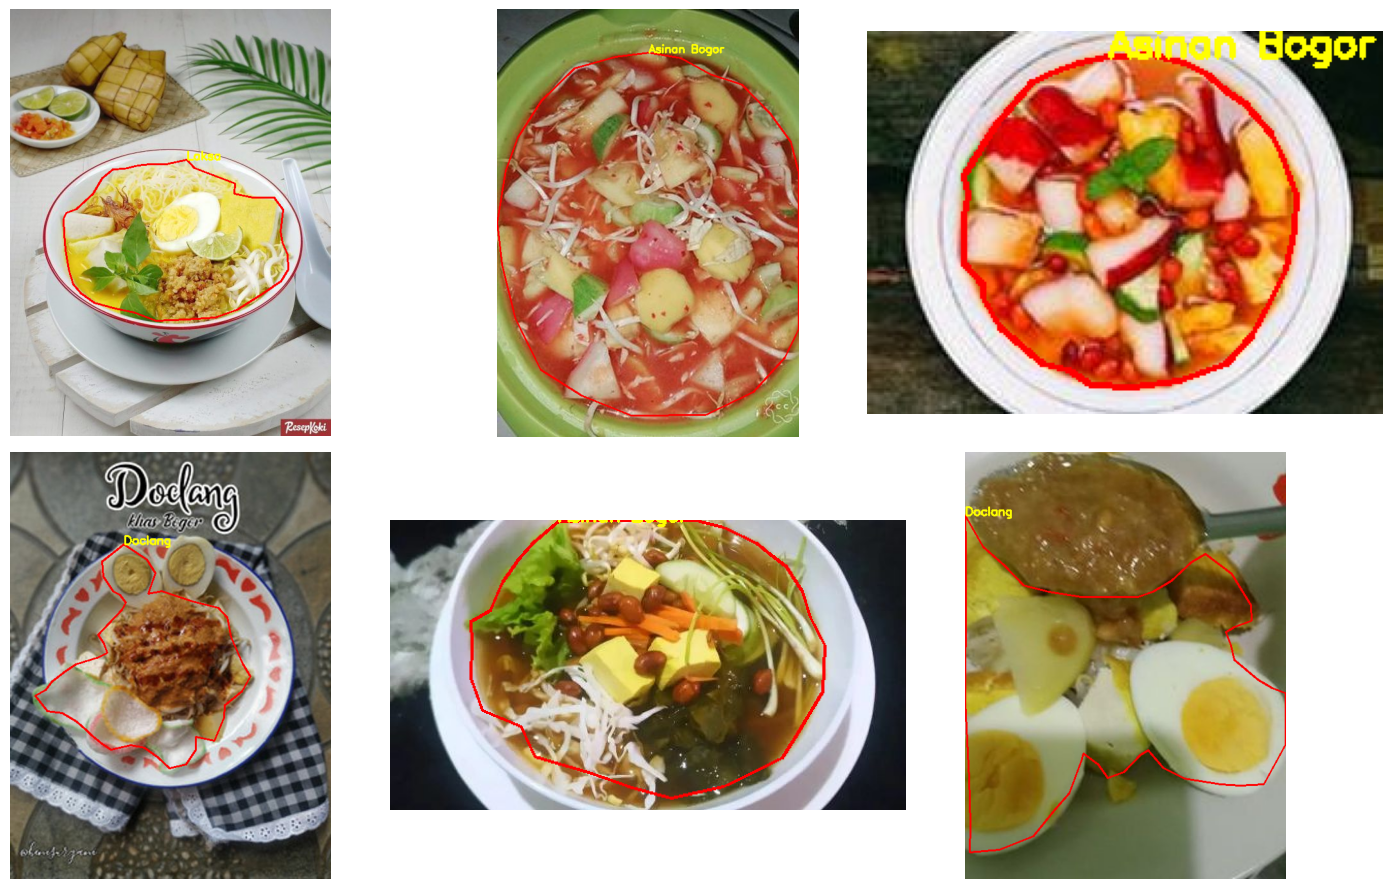

In [6]:
# Step 1 = ambil random gambar dari train
train_imgs = glob.glob(os.path.join(SOURCE_DIR, 'train', 'images', '*.*'))
sample = random.sample(train_imgs, min(6, len(train_imgs)))

# Step 2 = gambar polygon anotasi di atas tiap sample
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, img_path in zip(axes.flat, sample):
  img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
  h, w = img.shape[:2]
  label_path = img_path.replace('images', 'labels').rsplit('.', 1)[0] + '.txt'
  if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                p = line.split()
                if len(p) < 7:
                    continue
                cls_id = int(p[0])
                pts = np.array(p[1:], dtype=float).reshape(-1, 2)
                pts = (pts * [w, h]).astype(np.int32)
                cv2.polylines(img, [pts], True, (255, 0, 0), 2)
                cv2.putText(img, CLASS_NAMES[cls_id], tuple(pts[0]),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)
  ax.imshow(img)
  ax.axis('off')
plt.tight_layout()
plt.show()


#**3. DATA PREPARATION**

## 3.1 Data Cleaning

###3.1.1 Cek pasangan image-label

In [7]:
# Step 1 = Fungsi cek tiap gambar punya file label pasangannya
def cek_pasangan(split_dir):
  imgs = glob.glob(os.path.join(split_dir, 'images', '*.*'))
  img_stems = {Path(p).stem for p in imgs}
  lbl_stems = {Path(p).stem for p in glob.glob(os.path.join(split_dir, 'labels', '*.txt'))}
  img_tanpa_label = img_stems - lbl_stems
  label_tanpa_img = lbl_stems - img_stems
  return img_tanpa_label, label_tanpa_img

# Step 2 = Jalankan di folder train dan laporkakn yang nyasar
img_no_lbl, lbl_no_img = cek_pasangan(os.path.join(SOURCE_DIR, 'train'))
print(f"Gambar tanpa label: {len(img_no_lbl)}")
print(f"Label tanpa gambar: {len(lbl_no_img)}")
if img_no_lbl:
  print(" Contoh gambar tanpa label: ", list(img_no_lbl)[:5])


Gambar tanpa label: 0
Label tanpa gambar: 0


###3.1.2 Cek anotasi kosong dan gambar corrupt

In [8]:
# Step 1 = cari file label yang isinya kosong (0 polygon)
kosong = []
for txt in glob.glob(os.path.join(SOURCE_DIR, 'train', 'labels', '*.txt')):
  if os.path.getsize(txt) == 0:
    kosong.append(txt)
print(f"Label kosong: {len(kosong)}")

# Step 2 = cari gambar yang gagal dibaca
corrupt = []
for img_path in glob.glob(os.path.join(SOURCE_DIR, 'train', 'images', '*.*')):
  if cv2.imread(img_path) is None:
    corrupt.append(img_path)
print(f"Gambar corrupt: {len(corrupt)}")

Label kosong: 0
Gambar corrupt: 0


##3.2 Data Splitting

###3.2.1 Stratified split (70/20/10)


In [9]:
# Step 1 = siapkan folder kerja hasil split
SPLIT_DIR = '/content/dataset_split'
RATIO = {
    'train': 0.70,
    'valid' : 0.20,
    'test' : 0.10
}

# Step 2 = nantinya kalau pas export dari roboflow ada valid dant test, pake apa adanya, kalau tidak pake split dari train
haveValid = os.path.isdir(os.path.join(SOURCE_DIR, 'valid', 'images'))
haveTest = os.path.isdir(os.path.join(SOURCE_DIR, 'test', 'images'))

if haveValid and haveTest:
  DATASET_DIR = SOURCE_DIR
  print("Split valid & test sudah ada di export -> pakai langsung aja")
else:
  # Step 3: kelompokkan gambar train berdasarkan kelas dominannya (buat stratifikasi)
    def kelas_dominan(label_path):
        with open(label_path) as f:
            ids = [int(l.split()[0]) for l in f if l.strip()]
        return Counter(ids).most_common(1)[0][0] if ids else -1

    train_imgs = glob.glob(os.path.join(SOURCE_DIR, "train", "images", "*.*"))
    per_kelas = {}
    for img_path in train_imgs:
        lbl = img_path.replace("images", "labels").rsplit(".", 1)[0] + ".txt"
        if not os.path.exists(lbl):
            continue
        per_kelas.setdefault(kelas_dominan(lbl), []).append(img_path)

    # Step 4: bagi tiap kelas sesuai rasio, lalu salin ke folder split baru
    if os.path.exists(SPLIT_DIR):
        shutil.rmtree(SPLIT_DIR)
    for split in RATIO:
        os.makedirs(os.path.join(SPLIT_DIR, split, "images"), exist_ok=True)
        os.makedirs(os.path.join(SPLIT_DIR, split, "labels"), exist_ok=True)

    for cls_id, imgs in per_kelas.items():
        random.shuffle(imgs)
        n = len(imgs)
        n_train = int(n * RATIO["train"])
        n_valid = int(n * RATIO["valid"])
        bagian = {"train": imgs[:n_train],
                  "valid": imgs[n_train:n_train + n_valid],
                  "test":  imgs[n_train + n_valid:]}
        for split, files in bagian.items():
            for img_path in files:
                lbl = img_path.replace("images", "labels").rsplit(".", 1)[0] + ".txt"
                shutil.copy(img_path, os.path.join(SPLIT_DIR, split, "images"))
                if os.path.exists(lbl):
                    shutil.copy(lbl, os.path.join(SPLIT_DIR, split, "labels"))

    DATASET_DIR = SPLIT_DIR
    print("Split 70/20/10 dari train selesai.")

Split 70/20/10 dari train selesai.


###3.2.2 Update data.yaml

In [10]:
# Step 1: tulis data.yaml baru yang menunjuk ke folder split (path absolut)
new_yaml = {
    "train": os.path.join(DATASET_DIR, "train", "images"),
    "val":   os.path.join(DATASET_DIR, "valid", "images"),
    "test":  os.path.join(DATASET_DIR, "test",  "images"),
    "nc":    NC,
    "names": CLASS_NAMES,
}

# Step 2: simpan ke file dan pakai ini sebagai acuan training
YAML_PATH = os.path.join(DATASET_DIR, "data.yaml")
with open(YAML_PATH, "w") as f:
    yaml.safe_dump(new_yaml, f, sort_keys=False)
print(open(YAML_PATH).read())

train: /content/dataset_split/train/images
val: /content/dataset_split/valid/images
test: /content/dataset_split/test/images
nc: 5
names:
- Asinan Bogor
- Cungkring
- Doclang
- Laksa
- Toge Goreng



###3.2.3 Verifikasi distribusi per split

In [11]:
# Step 1 = pastikan tiap split kebagian semua kelas
for split in ['train', 'valid', 'test']:
  d = hitung_distribusi(os.path.join(DATASET_DIR, split, 'labels'))
  total = sum(d.values())
  ringkas = ', '.join(f"{k}={v}" for k, v in sorted(d.items()))
  print(f"{split:6s} (total {total}): {ringkas}")

train  (total 223): Asinan Bogor=58, Cungkring=39, Doclang=46, Laksa=39, Toge Goreng=41
valid  (total 62): Asinan Bogor=16, Cungkring=11, Doclang=13, Laksa=11, Toge Goreng=11
test   (total 38): Asinan Bogor=10, Cungkring=6, Doclang=8, Laksa=6, Toge Goreng=8


##3.3 Augmentasi

In [17]:
# Step 1 = definiskan param augmentasi (diterapkan yolo hanya)
# Dataset kecil -> augmentasi wajar saja, jangan ekstrem biar tidak merusak ciri makanan
AUG_PARAMS = dict(
    hsv_h=0.015, # geser warna (hue) tipis - warna makanan tetap
    hsv_s=0.5, # variasi saturasi - simulasi pecahayaan warung
    hsv_v=0, # variasi brightness - foto terang /gelap
    degrees=10, # rotasi keicl = priing bisa miring
    translate=0.1, # geser posisi objek
    scale=0.4, #variasi jarak ambil foto
    fliplr=0.5, # flip horizontal - makanan simetris, aman
    flipud=0.0, # tidak flip vertikla - priing tidak pernah terbalik
    mosaic=1.0, # gabung 4 gambar - efektif menambah variasi konteks
    mixup=0.0, # dimatikan == bikin ambigu untuk klasifikasi
    copy_paste=0.0 # dimatikan == tidak relevan
)
print("Parameter augmentasi (trian-only):")
for k, v in AUG_PARAMS.items():
  print(f" {k:12s}= {v}")

Parameter augmentasi (trian-only):
 hsv_h       = 0.015
 hsv_s       = 0.5
 hsv_v       = 0
 degrees     = 10
 translate   = 0.1
 scale       = 0.4
 fliplr      = 0.5
 flipud      = 0.0
 mosaic      = 1.0
 mixup       = 0.0
 copy_paste  = 0.0


#**4. MODELING**

##4.1 Konfigurasi Training (Hyperparameter)

In [18]:
# Step 1 = pilih arsitektur
MODEL_ARCH = 'yolov8n-seg.pt'

# Step 2 = parameter utama training
TRAIN_PARAMS = dict(
    epochs=100, # batas atas; early stoping yang menentukan berhenti
    patience=20, # early stopping; stop kalau 20 epcoh val tidak membaik
    imgsz=640, # resolusi input standar YOLOv8
    batch=16, # sesuaikan dgn vram colab
    optimizer="AdamW", # stabil untuk transfer learing di data
    lr0=0.001, # learning rate awal - kecil karena fine-tuning
    lrf=0.01, # lr akhir = lr0 *lrf (decay bertahap)
    momentum=0.937,
    weight_decay=0.0005, # regularisasi - peting untuk data keicl
    warmup_epochs=3,
    cos_lr=True,
    freeze=10,
    seed=SEED
)

# Step 3 = gabung dengan paramter augmentasi dari sel sebelumnya
FULL_PARAMS = {**TRAIN_PARAMS, **AUG_PARAMS}
print("Konfigurasi trainign final:")
for k, v in FULL_PARAMS.items():
  print(f' {k:14s}= {v}')

Konfigurasi trainign final:
 epochs        = 100
 patience      = 20
 imgsz         = 640
 batch         = 16
 optimizer     = AdamW
 lr0           = 0.001
 lrf           = 0.01
 momentum      = 0.937
 weight_decay  = 0.0005
 warmup_epochs = 3
 cos_lr        = True
 freeze        = 10
 seed          = 42
 hsv_h         = 0.015
 hsv_s         = 0.5
 hsv_v         = 0
 degrees       = 10
 translate     = 0.1
 scale         = 0.4
 fliplr        = 0.5
 flipud        = 0.0
 mosaic        = 1.0
 mixup         = 0.0
 copy_paste    = 0.0


##4.2 Load Pretrained Model

In [19]:
# Step 1 = load bobot pretrained COCO (transfer learning)
model = YOLO(MODEL_ARCH)
print(f'Model {MODEL_ARCH} termuat. Task: {model.task}')

Model yolov8n-seg.pt termuat. Task: segment


##4.3 Training

In [20]:
# Step 1 = latih model dengan konfigruasi + augmentasi yang sudah disiapkan
results = model.train(
    data=YAML_PATH,
    project='bogor_yolo',
    name='seg_run',
    **FULL_PARAMS
)

# Step 2 = catat lokasi mfolder hasil (bobot best.pt & grafik ada di sini)
RUN_DIR = str(results.save_dir)
print(f"Training selesai. Hasil di: {RUN_DIR}")

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset_split/data.yaml, degrees=10, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.015, hsv_s=0.5, hsv_v=0, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=seg_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_m

##4.4 Kurva Training

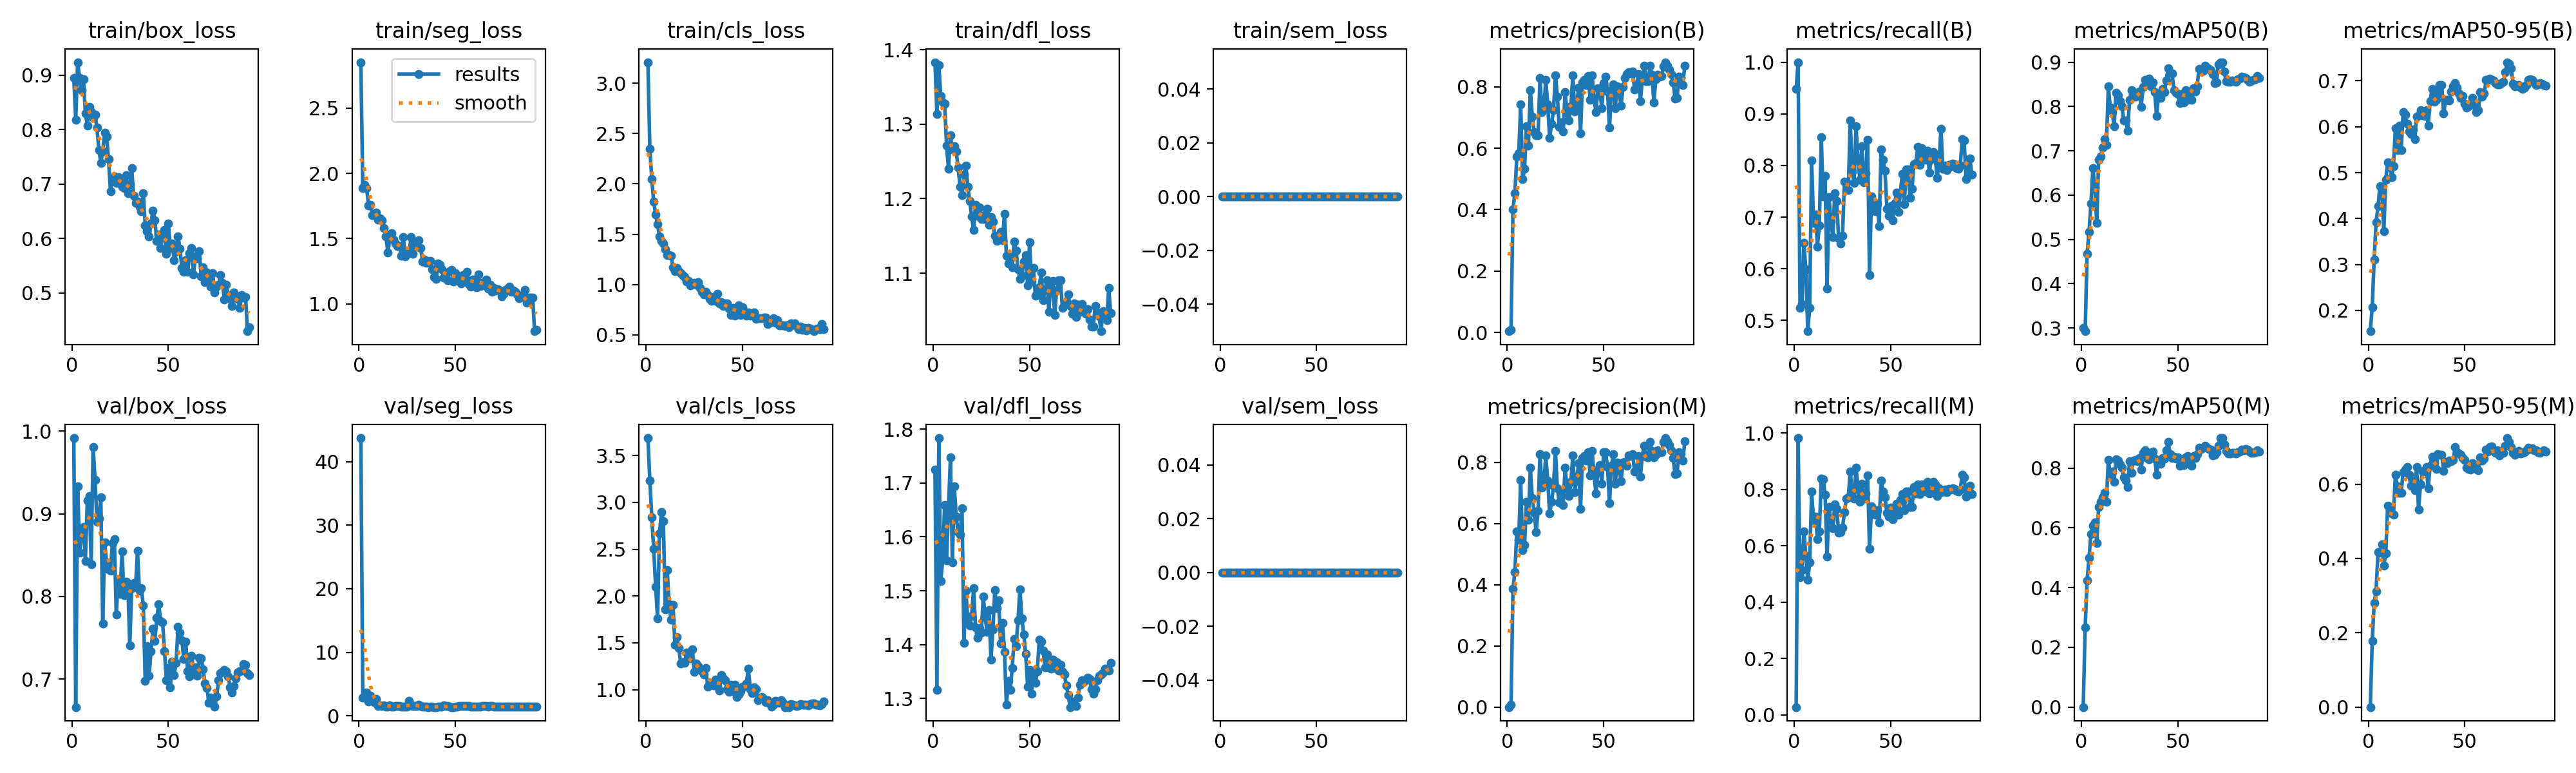

In [23]:
# Step 1 = tampilan grafik hasil training bawaan YOLO (loss, mAP, precision, recall)
results_png = os.path.join(RUN_DIR, 'results.png')
if os.path.exists(results_png):
  display(Image(filename=results_png))

#**5. Evaluation**

##5.1 Validasi (mAP)

In [24]:
# Step 1 = evaluasi model terbaik pada split test
BEST_WEIGHTS = os.path.join(RUN_DIR, 'weights', 'best.pt')
best_model = YOLO(BEST_WEIGHTS)

# Step 2 = hitung metrik
metrics = best_model.val(data=YAML_PATH, split='test')
print(f"mAP50         : {metrics.seg.map50:.4f}")
print(f"mAP50-95      : {metrics.seg.map:.4f}")

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,259,039 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1197.7±597.4 MB/s, size: 36.0 KB)
val: Scanning /content/dataset_split/test/labels... 36 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 36/36 1.5Kit/s 0.0s
val: New cache created: /content/dataset_split/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.1s/it 3.4s
                   all         36         38      0.881      0.834      0.927      0.735      0.881      0.834      0.927      0.759
          Asinan Bogor          9         10      0.934        0.8      0.913      0.767      0.934        0.8      0.913      0.779
             Cungkring          6          6      0.939          1      0.995      0.616      0.939          1      0.9

##5.2 Confusion Matrix & Metrik per Kelas

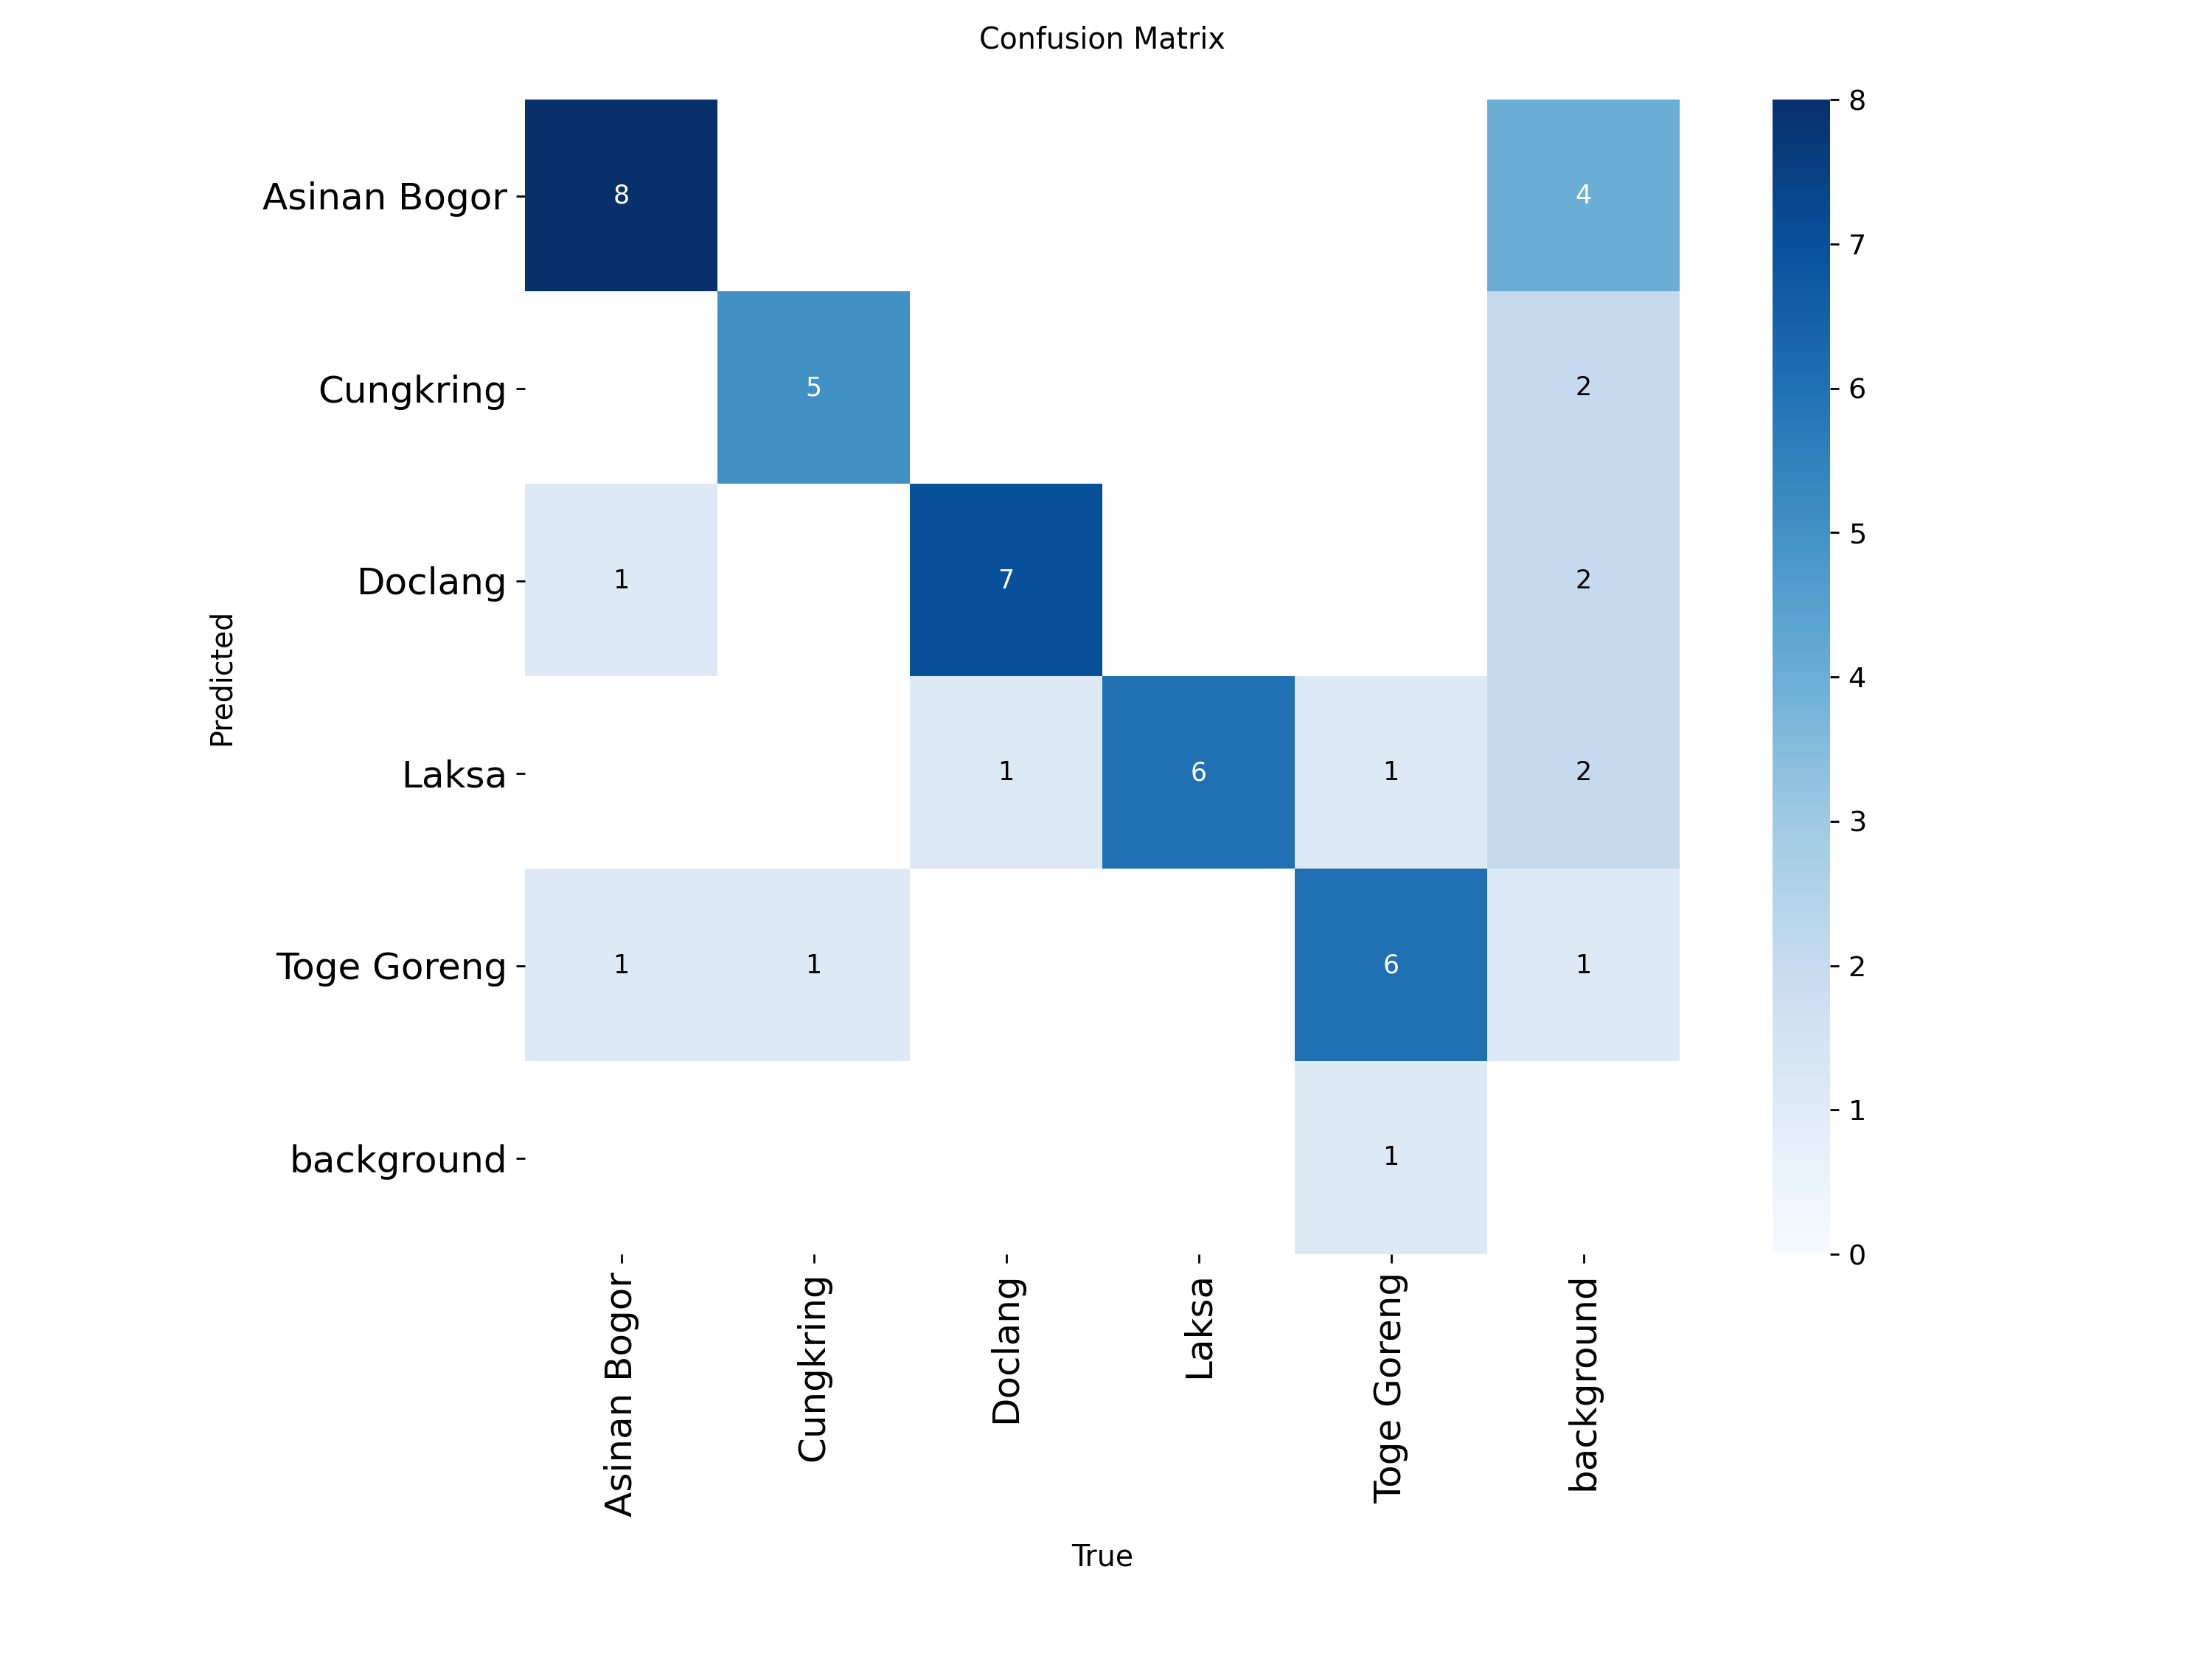

Cungkring       : mAP50-95 = 0.7791
Cungkring       : mAP50-95 = 0.7587
Cungkring       : mAP50-95 = 0.7287
Cungkring       : mAP50-95 = 0.8475
Cungkring       : mAP50-95 = 0.6828


In [25]:
# Step 1 = tampilkan cf hasil validasi
cm_png = os.path.join(str(metrics.save_dir), 'confusion_matrix.png')
if os.path.exists(cm_png):
  display(Image(filename=cm_png))

# Step 2 = mAP50-95 per kelas biar keliatan kelas mana yang lemah
for i, name in enumerate(CLASS_NAMES):
  try:
    print(f"{nama:16s}: mAP50-95 = { metrics.seg.maps[i]:.4f}")
  except Exception:
    pass

##5.3 Prediksi Sample Test

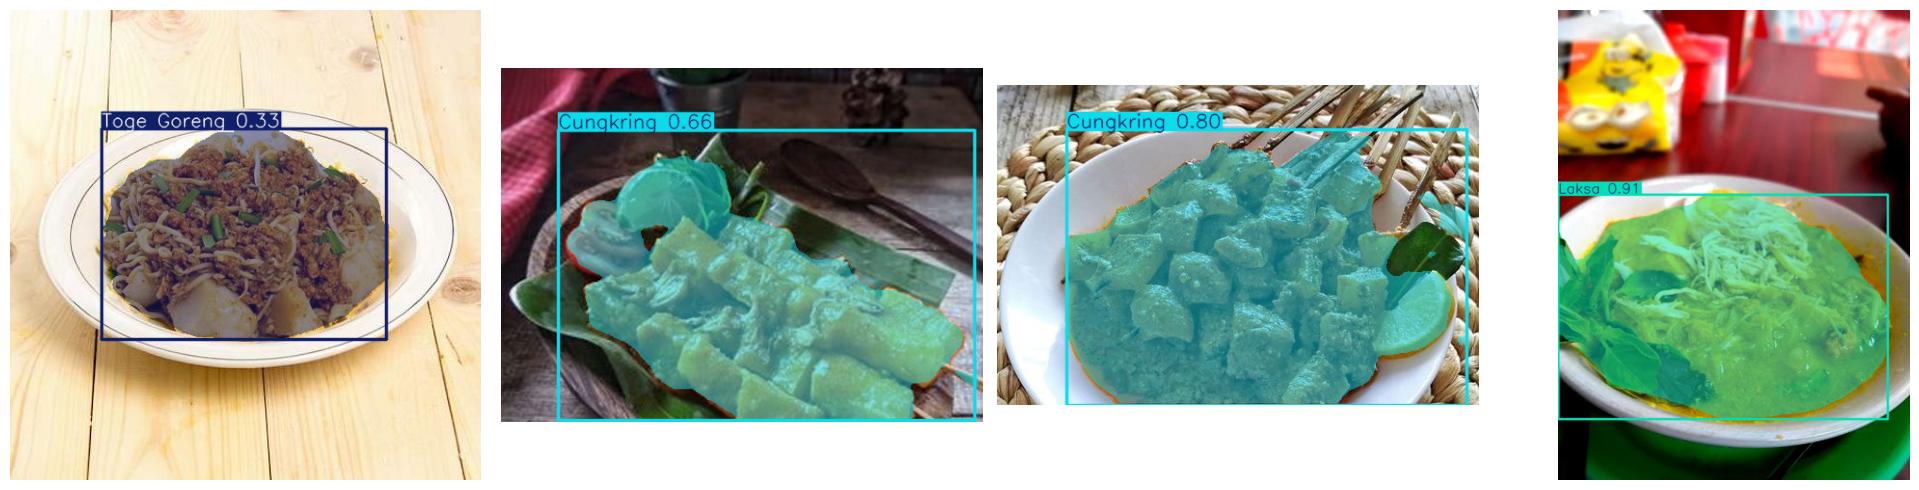

In [27]:
# Step 1 = ambil beberapa gambar test dan jalankan prediksi
test_imgs = glob.glob(os.path.join(DATASET_DIR, 'test', 'images', '*.*'))
sample_test = random.sample(test_imgs, min(4, len(test_imgs)))

# Step 2 = tampilkan hasil deteksi (mask + label + confidence)
fig, axes = plt.subplots(1, len(sample_test), figsize=(5 * len(sample_test), 5))
if len(sample_test) == 1:
  axes = [axes]
for ax, img_path in zip(axes, sample_test):
    res = best_model.predict(img_path, conf=0.25, verbose=False)
    ax.imshow(cv2.cvtColor(res[0].plot(), cv2.COLOR_BGR2RGB))
    ax.axis("off")
plt.tight_layout()
plt.show()

#**6. Deployment**

##6.1 Export Model

In [29]:
# Step 1 = salin bobot terbaik ke drive
EXPORT_PATH = '/content/drive/MyDrive/Nutrify_AI_Mobile-PI-Gundar/Model/bogor_yolo_best.pt'
shutil.copy(BEST_WEIGHTS, EXPORT_PATH)
print(f"Bobot model tersimpan: {EXPORT_PATH}")

Bobot model tersimpan: /content/drive/MyDrive/Nutrify_AI_Mobile-PI-Gundar/Model/bogor_yolo_best.pt


##6.2 Bridge Demo: Deteksi Dish -> Lookup Nutrisi

###6.2.1 Load model & prediksi 1 gambar

In [30]:
# Step 1 = Jalankan model ke satu gambar test sebagai simu input dari app
demo_img = random.choice(test_imgs)
res = best_model.predict(demo_img, conf=0.25, verbose=False)
r = res[0]


# Step 2: ambil kelas dengan confidence tertinggi sebagai dish terdeteksi
if len(r.boxes) > 0:
    top = int(r.boxes.conf.argmax())
    cls_id = int(r.boxes.cls[top])
    conf = float(r.boxes.conf[top])
    dish_terdeteksi = best_model.names[cls_id]
    print(f"Dish terdeteksi: {dish_terdeteksi} (conf {conf:.2f})")
else:
    dish_terdeteksi = None
    print("Tidak ada dish terdeteksi.")

Dish terdeteksi: Doclang (conf 0.64)


###6.2.2 Lookup nutrisi dari clean_dataset.csv


In [33]:
# Step 1: baca CSV nutrisi (dataset tabular) - hanya BACA, tidak diolah ulang
CSV_PATH = "/content/drive/MyDrive/Nutrify_AI_Mobile-PI-Gundar/Datasets/Dataset_Tabular/clean_dataset.csv"
nutrisi = pd.read_csv(CSV_PATH)

# Step 2: cocokkan nama kelas YOLO ke kolom food_name (lowercase = kunci penghubung)
if dish_terdeteksi:
    key = dish_terdeteksi.lower().strip()
    baris = nutrisi[nutrisi["food_name"].str.lower().str.strip() == key]

    # Step 3: tampilkan info gizi kalau ketemu
    if not baris.empty:
        g = baris.iloc[0]
        print(f"Nutrisi '{dish_terdeteksi}' (per 100g):")
        print(f"  Kalori       : {g['calories']} kkal")
        print(f"  Protein      : {g['protein']} g")
        print(f"  Lemak        : {g['fat']} g")
        print(f"  Karbohidrat  : {g['carbohydrates']} g")
        print(f"  Kategori     : {g['calorie_category']}")
    else:
        print(f"'{key}' tidak ditemukan di CSV - cek konsistensi nama kelas vs food_name.")

Nutrisi 'Doclang' (per 100g):
  Kalori       : 215.0 kkal
  Protein      : 7.5 g
  Lemak        : 9.5 g
  Karbohidrat  : 26.0 g
  Kategori     : sedang
